In [1]:
print("="*70)
print("UNIVARIATE COX REGRESSION PIPELINE")
print("="*70)

UNIVARIATE COX REGRESSION PIPELINE


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, proportional_hazard_test
from lifelines.utils import concordance_index
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10, 
                    'axes.titlesize': 11, 'figure.facecolor': 'white'})

In [3]:
input_csv = "09_TARGET_model_ready.csv"
output_dir = "TARGET_univariate_cox_outputs"
os.makedirs(output_dir, exist_ok=True)

#may set threshold to 0.10 for more inclusive candidate list for LASSO
p_threshold = 0.10

endpoints = [
    ("OS", "OS.status", "Overall Survival (OS)"), 
    ("EFS", "EFS.status", "Event-Free Survival (EFS)"), 
    ("DFS", "DFS.status", "Disease-Free Survival (DFS)"),
]

primary_duration = "OS"
primary_event = "OS.status"

continuous_vars = [
    "Age.at.Diagnosis.in.Years",
    "WBC.at.Diagnosis",
    "WBC_log",                                # log-transformed WBC
    "Percent.Blasts.Tumor.Sample.Diagnostic",
    "Germline.with.Tumor.Contamination.%.Blasts",
]

binary_ordinal_vars = [
    "Sex",                            # 0=Female, 1=Male
    "ETP.STATUS",                     # 0=non-ETP, 1=ETP
    "CNS.Status",                     # 1/2/3 ordinal
    "Day.29.MRD",                     # 0=Neg, 1=LowPos, 2=Pos
    "End.of.Consolidation.MRD",       # same scale
    "Day.29.morphologic.Response",    # M1/M2/M3 → 1/2/3
    "Death_recorded",                 # missingness flag from EDA
    "Had_Relapse_Specimen",           # proxy for relapse occurrence
    "Day29_MRD_tested",               # whether MRD was tested
    "In.TARGET.Cohort.(n=.264).RNASeq.and.WES",
]

binary_ordinal_vars = [v for v in binary_ordinal_vars if v != 'Day.29.MRD']
continuous_vars.append('Day.29.MRD')

In [4]:
#reload the model-ready CSV rather than re-running EDA
#this script is self-contained and reproducible

df = pd.read_csv(input_csv)
print(f"  Shape: {df.shape[0]} patients × {df.shape[1]} columns")

  Shape: 1335 patients × 30 columns


In [5]:
for dur, evt, _ in endpoints:
    if dur in df.columns:
        df[dur] = pd.to_numeric(df[dur], errors='coerce')
    if evt in df.columns:
        df[evt] = pd.to_numeric(df[evt], errors='coerce')

known_cols = (continuous_vars + binary_ordinal_vars +
              [d for d, e, _ in endpoints] +
              [e for d, e, _ in endpoints] +
              ["USI", "patient_id"])

dummy_cols = [
    c for c in df.columns
    if c not in known_cols
    and "_" in c
    and df[c].dtype in ['int64', 'float64', 'int32', 'uint8']
    and df[c].nunique() <= 3
    and not c.startswith("Event.Type_")        # ← ADD: these ARE the outcome
    and not c.startswith("Germline.Specimen.")  # ← ADD: sample logistics
    and not c.startswith("Tumor.Specimen.")     # ← ADD: sample logistics
]

#final candidate list - only keep columns actually present in the CSV
all_candidate_vars = []
for col in continuous_vars + binary_ordinal_vars + dummy_cols:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        if n_valid >= 10:           # skip near-empty columns
            all_candidate_vars.append(col)
        else:
            print(f"  Skipped '{col}': only {n_valid} non-null values")

if "WBC_log" in all_candidate_vars and "WBC.at.Diagnosis" in all_candidate_vars:
    all_candidate_vars.remove("WBC.at.Diagnosis")
    print("  Note: Using WBC_log instead of raw WBC.at.Diagnosis")

print(f"\n  Candidate variables for Cox: {len(all_candidate_vars)}")
for v in all_candidate_vars:
    print(f"    {v}")

print(f"\n  Endpoints: {[ep[2] for ep in endpoints]}")
print(f"  Significance threshold: p < {p_threshold}")

  Skipped 'Germline.with.Tumor.Contamination.%.Blasts': only 8 non-null values
  Skipped 'CNS.Status': only 0 non-null values
  Skipped 'End.of.Consolidation.MRD': only 0 non-null values
  Note: Using WBC_log instead of raw WBC.at.Diagnosis

  Candidate variables for Cox: 9
    Age.at.Diagnosis.in.Years
    WBC_log
    Percent.Blasts.Tumor.Sample.Diagnostic
    Day.29.MRD
    Sex
    ETP.STATUS
    Death_recorded
    Had_Relapse_Specimen
    Day29_MRD_tested

  Endpoints: ['Overall Survival (OS)', 'Event-Free Survival (EFS)', 'Disease-Free Survival (DFS)']
  Significance threshold: p < 0.1


In [6]:
print("="*70)
print("STEP 1: RUNNING UNIVARIATE COX FOR ALL VARIABLES X ALL ENDPOINTS")
print("="*70)

STEP 1: RUNNING UNIVARIATE COX FOR ALL VARIABLES X ALL ENDPOINTS


In [7]:
import re
import numpy as np

def safe_formula(var):
    if re.search(r'[\s\-\(\)]', var):
        return f'`{var}`'
    return var

def has_complete_separation(subset, duration_col, event_col, var):
    """Return True if the binary variable perfectly separates events from non-events."""
    if subset[var].nunique() != 2:
        return False
    events = subset[subset[event_col] == 1][var]
    return events.nunique() < 2  # all events in one group only

vars_to_remove = ["Day29_MRD_tested", "Death_recorded"]
all_candidate_vars = [v for v in all_candidate_vars if v not in vars_to_remove]

COEF_EXPLOSION_THRESHOLD = 10  # |coef| > 10 → HR > ~22000: almost certainly separation

all_results = {}
for duration_col, event_col, ep_label in endpoints:
    if duration_col not in df.columns or event_col not in df.columns:
        print(f"  Skipping {ep_label} — columns not found")
        continue
    print(f"  ── {ep_label} ──")
    ep_results = []

    for var in all_candidate_vars:
        subset = df[[duration_col, event_col, var]].dropna()

        for col in subset.select_dtypes(include='object').columns:
            subset[col] = subset[col].str.replace(" ", "_", regex=False)

        n_patients = len(subset)
        n_events   = int(subset[event_col].sum())

        if n_patients < 10:
            print(f"    SKIP '{var}': n={n_patients} too small")
            continue
        if n_events < 5:
            print(f"    SKIP '{var}': only {n_events} events — unreliable HR")
            continue
        if subset[var].nunique() < 2:
            print(f"    SKIP '{var}': no variation (all same value)")
            continue
        if subset[var].dtype == object and subset[var].nunique() > 2:
            print(f"    SKIP '{var}': string column with {subset[var].nunique()} levels — dummy-encode first")
            continue

        # Detect complete separation before fitting
        if has_complete_separation(subset, duration_col, event_col, var):
            print(f"    SKIP '{var}': complete separation — all events in one group, HR undefined")
            continue

        formula = safe_formula(var)
        sanitized_var = var.replace(" ", "_")

        cph = CoxPHFitter(penalizer=0.1)  # small ridge penalty helps borderline cases
        try:
            cph.fit(subset,
                    duration_col=duration_col,
                    event_col=event_col,
                    formula=formula)

            summary = cph.summary
            possible_keys = [var, sanitized_var, formula.strip('`')]
            row_key = next((k for k in possible_keys if k in summary.index), None)
            if row_key is None:
                row_key = summary.index[0]

            coef    = float(summary.loc[row_key, 'coef'])
            hr      = float(summary.loc[row_key, 'exp(coef)'])
            hr_lo   = float(summary.loc[row_key, 'exp(coef) lower 95%'])
            hr_hi   = float(summary.loc[row_key, 'exp(coef) upper 95%'])
            p_val   = float(summary.loc[row_key, 'p'])
            z_score = float(summary.loc[row_key, 'z'])

            # Post-fit sanity check: exploded coefficient = separation not caught pre-fit
            if abs(coef) > COEF_EXPLOSION_THRESHOLD or not np.isfinite(hr):
                print(f"    SKIP '{var}': coefficient explosion (coef={coef:.1f}) — likely separation")
                continue

            # p=nan means the model produced no valid inference
            if not np.isfinite(p_val):
                print(f"    SKIP '{var}': p=nan — model did not converge cleanly")
                continue

            c_idx = concordance_index(
                subset[duration_col],
                -cph.predict_partial_hazard(subset),
                subset[event_col]
            )

            ep_results.append({
                "variable"   : var.replace(".", " ").replace("_", " "),
                "n"          : n_patients,
                "n_events"   : n_events,
                "coef"       : round(coef, 4),
                "HR"         : round(hr, 3),
                "HR_lower95" : round(hr_lo, 3),
                "HR_upper95" : round(hr_hi, 3),
                "z"          : round(z_score, 3),
                "p_value"    : round(p_val, 4),
                "significant": p_val < p_threshold,
                "C_index"    : round(c_idx, 3),
                "endpoint"   : ep_label,
            })

            sig_marker = "✓" if p_val < p_threshold else " "
            direction  = "↑ risk" if hr > 1 else "↓ risk"
            print(f"    {sig_marker} {var:<50} "
                  f"HR={hr:.3f} [{hr_lo:.3f}–{hr_hi:.3f}]  "
                  f"p={p_val:.4f}  {direction}")

        except Exception as ex:
            print(f"    ERROR fitting '{var}': {ex}")

    if not ep_results:
        print(f"  No results collected for '{ep_label}' — all fits failed.")
        continue

    results_df = pd.DataFrame(ep_results).sort_values("p_value")
    all_results[ep_label] = results_df
    n_sig = results_df['significant'].sum()
    print(f"\n  {n_sig}/{len(results_df)} variables significant at p<{p_threshold}")

    safe_label = ep_label.replace(" ", "_").replace("(", "").replace(")", "")
    results_df.to_csv(f"{output_dir}/01_univariate_cox_{safe_label}.csv", index=False)
    print(f"  Results saved → {output_dir}/01_univariate_cox_{safe_label}.csv")

  ── Overall Survival (OS) ──
      Age.at.Diagnosis.in.Years                          HR=1.010 [0.988–1.033]  p=0.3702  ↑ risk
      WBC_log                                            HR=1.179 [0.803–1.730]  p=0.4015  ↑ risk
      Percent.Blasts.Tumor.Sample.Diagnostic             HR=0.998 [0.991–1.006]  p=0.6734  ↓ risk
    ✓ Day.29.MRD                                         HR=1.025 [1.017–1.032]  p=0.0000  ↑ risk
      Sex                                                HR=1.025 [0.782–1.344]  p=0.8591  ↑ risk
    SKIP 'ETP.STATUS': string column with 3 levels — dummy-encode first
    SKIP 'Had_Relapse_Specimen': no variation (all same value)

  1/5 variables significant at p<0.1
  Results saved → TARGET_univariate_cox_outputs/01_univariate_cox_Overall_Survival_OS.csv
  ── Event-Free Survival (EFS) ──
      Age.at.Diagnosis.in.Years                          HR=0.995 [0.975–1.015]  p=0.6226  ↓ risk
      WBC_log                                            HR=1.180 [0.855–1.629]  p=0.

In [8]:
print("="*70)
print("STEP 2: FOREST PLOTS")
print("="*70)

STEP 2: FOREST PLOTS


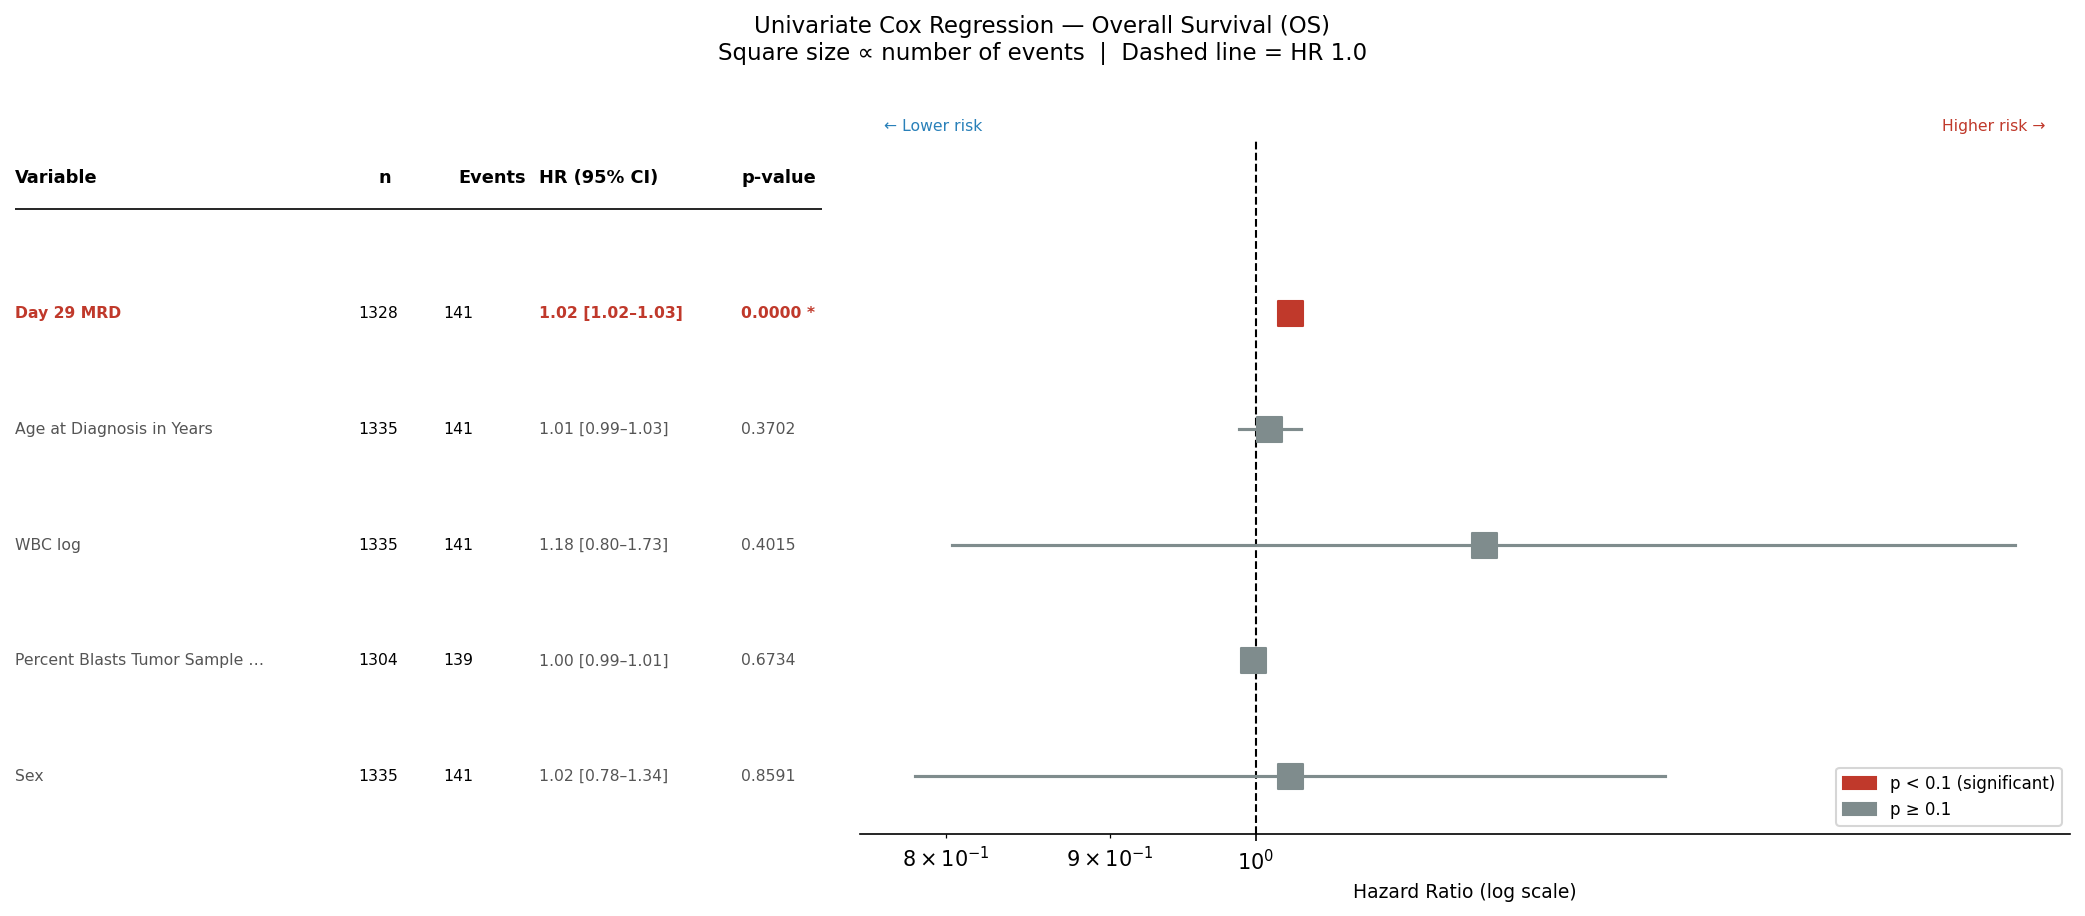

  Forest plot saved → TARGET_univariate_cox_outputs/02_forest_plot_Overall_Survival_OS.png


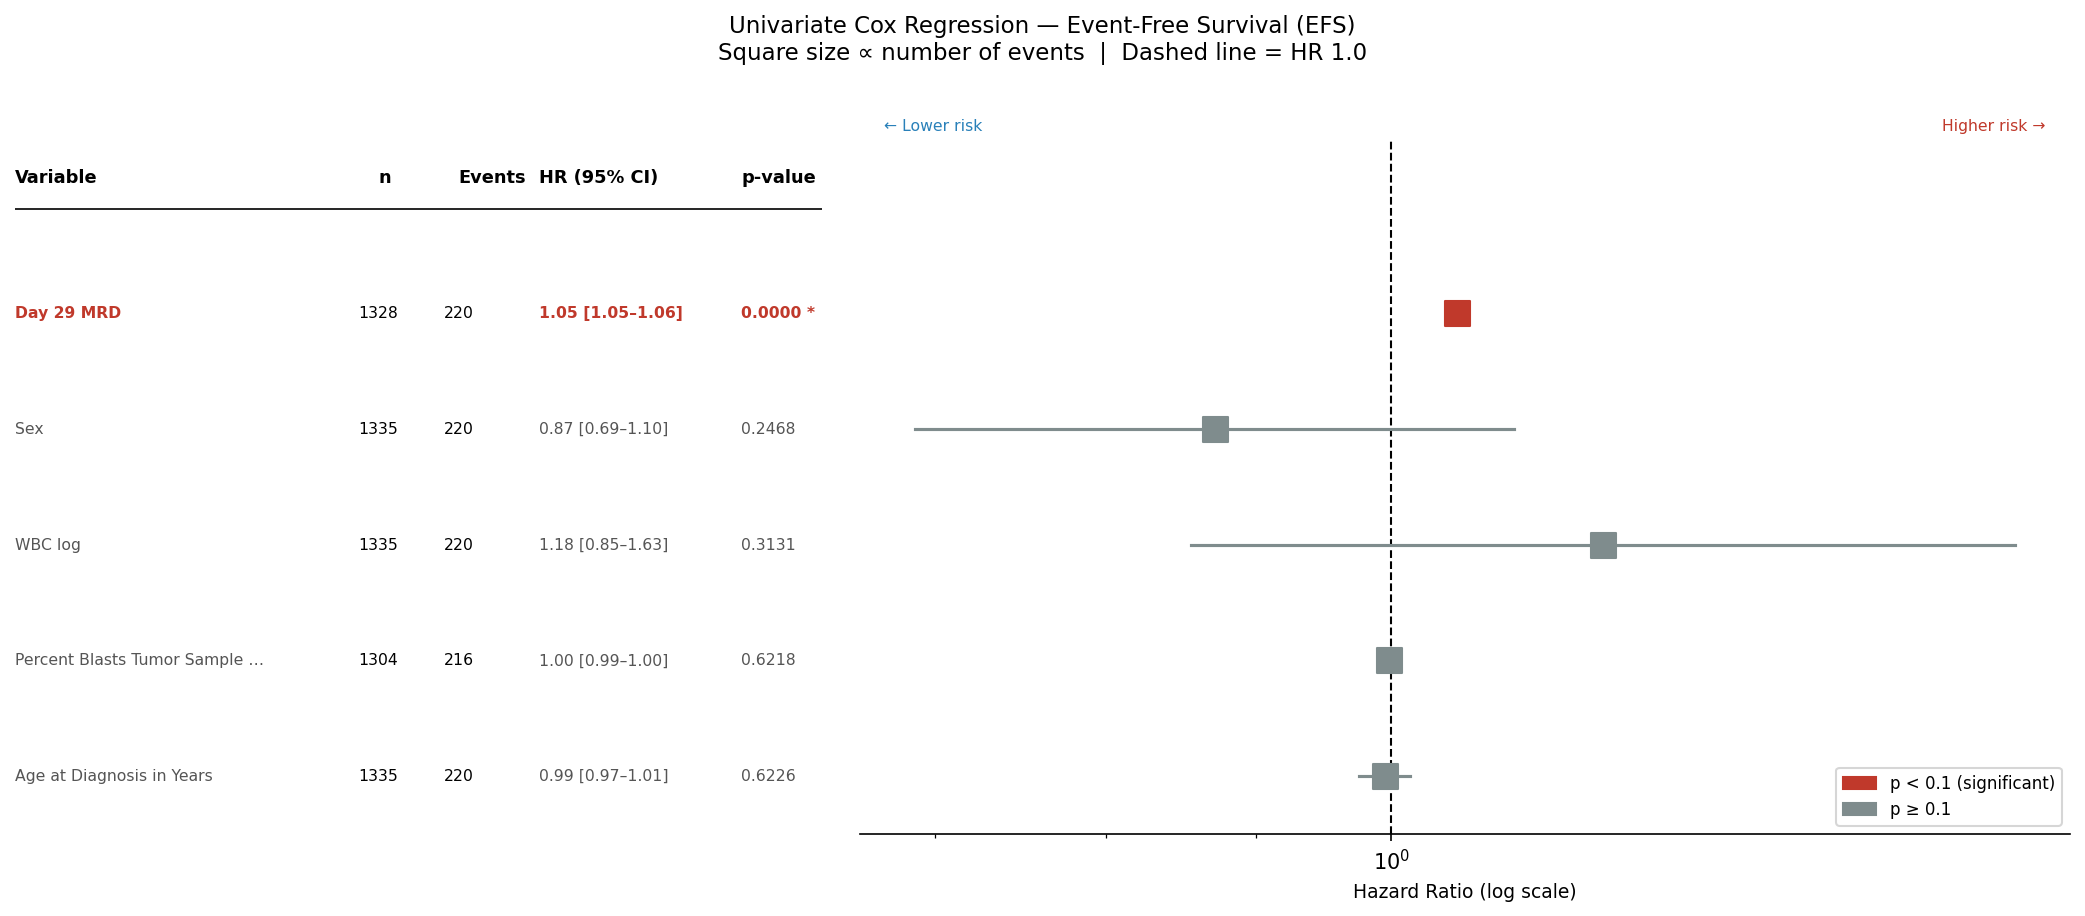

  Forest plot saved → TARGET_univariate_cox_outputs/02_forest_plot_Event-Free_Survival_EFS.png


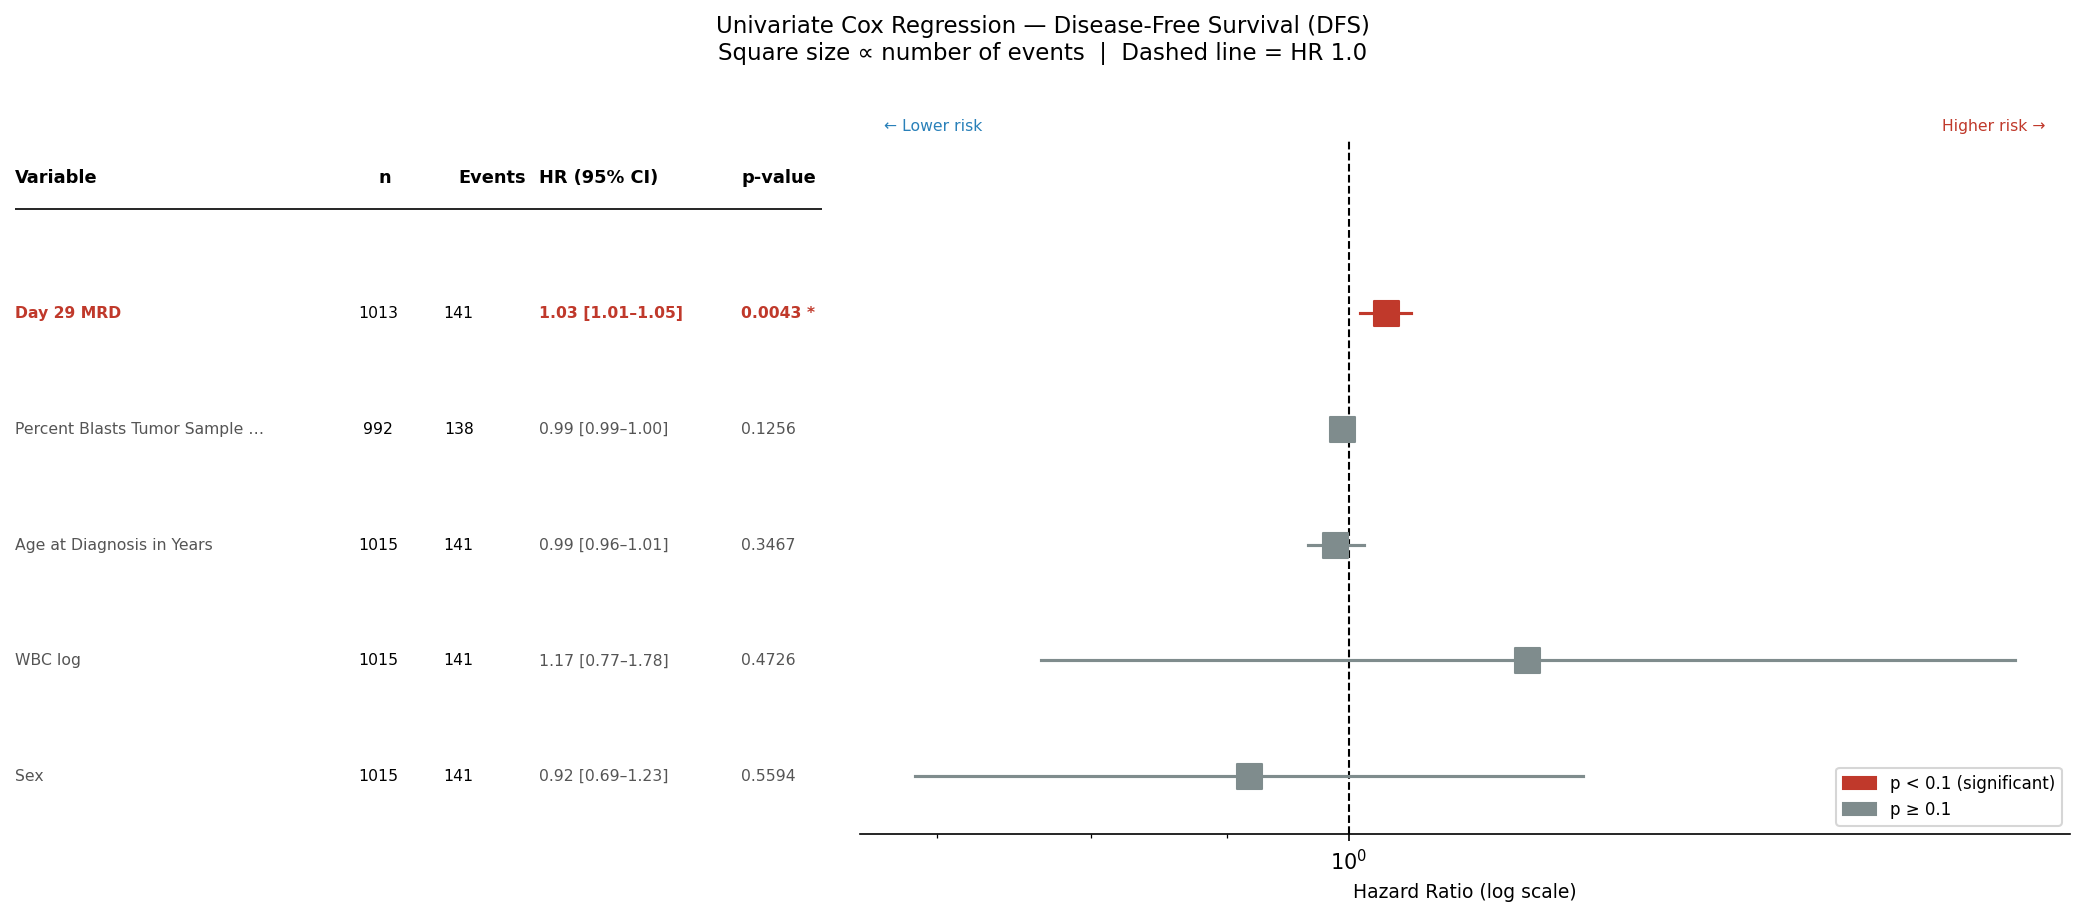

  Forest plot saved → TARGET_univariate_cox_outputs/02_forest_plot_Disease-Free_Survival_DFS.png


In [11]:
def forest_plot(results_df, endpoint_label, output_path, p_thresh=0.05):
    """
    Draw a publication-style forest plot for univariate Cox results.

    Parameters
    ----------
    results_df    : DataFrame with columns HR, HR_lower95, HR_upper95, p_value
    endpoint_label: string label for the plot title
    output_path   : where to save the PNG
    p_thresh      : significance threshold line
    """
    df_plot = results_df.copy().sort_values("p_value")
    n = len(df_plot)
    if n == 0:
        print(f"  No results to plot for {endpoint_label}")
        return
    fig_height = max(6, n * 0.45 + 2)
    fig, (ax_table, ax_forest) = plt.subplots(
        1, 2, figsize=(14, fig_height),
        gridspec_kw={'width_ratios': [2, 3]}
    )

    ax_table.set_xlim(0, 1)
    ax_table.set_ylim(-0.5, n + 0.5)
    ax_table.axis('off')

    #column headers
    headers = ["Variable", "n", "Events", "HR (95% CI)", "p-value"]
    col_x   = [0.0, 0.45, 0.55, 0.65, 0.90]
    for hx, hdr in zip(col_x, headers):
        ax_table.text(hx, n + 0.1, hdr, fontsize=8.5, fontweight='bold',
                      va='bottom')
    ax_table.axhline(n - 0.1, color='black', lw=0.8)
 
    for row_i, (_, row) in enumerate(df_plot.iterrows()):
        y      = n - 1 - row_i
        color  = '#C0392B' if row['p_value'] < p_thresh else '#555555'
        weight = 'bold' if row['p_value'] < p_thresh else 'normal'

        clean = row['variable'].replace('.', ' ').replace('_', ' ')
        varname = (clean[:28] + '…') if len(clean) > 30 \
            else clean
     
        ax_table.text(col_x[0], y, varname, fontsize=7.5, va='center',
                          color=color, fontweight=weight)
        ax_table.text(col_x[1], y, str(row['n']),
                          fontsize=7.5, va='center', ha='center')
        ax_table.text(col_x[2], y, str(row['n_events']),
                          fontsize=7.5, va='center', ha='center')
        ci_str = f"{row['HR']:.2f} [{row['HR_lower95']:.2f}–{row['HR_upper95']:.2f}]"
        ax_table.text(col_x[3], y, ci_str, fontsize=7.5, va='center',
                          color=color, fontweight=weight)
        p_str = f"{row['p_value']:.4f}" + (" *" if row['p_value'] < p_thresh else "")
        ax_table.text(col_x[4], y, p_str, fontsize=7.5, va='center',
                    color=color, fontweight=weight)

    ax_forest.set_xscale('log')
    ax_forest.set_ylim(-0.5, n + 0.5)
    ax_forest.axvline(1.0, color='black', lw=1.0, ls='--', zorder=1)
 
    for row_i, (_, row) in enumerate(df_plot.iterrows()):
        y     = n - 1 - row_i
        color = '#C0392B' if row['p_value'] < p_thresh else '#7F8C8D'

        ax_forest.plot([row['HR_lower95'], row['HR_upper95']], [y, y],
                       color=color, lw=1.5, zorder=2)

        marker_size = max(4, min(12, row['n_events'] / 5))
        ax_forest.scatter(row['HR'], y, color=color, s=marker_size**2,
                          zorder=3, marker='s')

    ax_forest.set_xlabel("Hazard Ratio (log scale)", fontsize=9)
    ax_forest.set_yticks([])
    ax_forest.spines['left'].set_visible(False)
    ax_forest.spines['right'].set_visible(False)
    ax_forest.spines['top'].set_visible(False)

    sig_patch   = mpatches.Patch(color='#C0392B', label=f'p < {p_thresh} (significant)')
    insig_patch = mpatches.Patch(color='#7F8C8D', label=f'p ≥ {p_thresh}')
    ax_forest.legend(handles=[sig_patch, insig_patch], loc='lower right',
                     fontsize=8)

    ax_forest.text(0.02, 1.01, '← Lower risk', transform=ax_forest.transAxes,
                   fontsize=7.5, color='#2980B9', va='bottom')
    ax_forest.text(0.98, 1.01, 'Higher risk →', transform=ax_forest.transAxes,
                   fontsize=7.5, color='#C0392B', va='bottom', ha='right')

    plt.suptitle(f"Univariate Cox Regression — {endpoint_label}\n"
                 f"Square size ∝ number of events  |  Dashed line = HR 1.0",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    plt.savefig(output_path, bbox_inches='tight')
    plt.close()
    print(f"  Forest plot saved → {output_path}")
 
 
for ep_label, results_df in all_results.items():
    safe = ep_label.replace(" ", "_").replace("(", "").replace(")", "")
    forest_plot(results_df, ep_label,
                f"{output_dir}/02_forest_plot_{safe}.png",
                p_thresh=p_threshold)
 
 
            

In [12]:
print("="*70)
print("STEP 3: PROPORTIONAL HAZARDS ASSUMPTION CHECK")
print("="*70)

STEP 3: PROPORTIONAL HAZARDS ASSUMPTION CHECK


Cox regression assumes the hazard ration between any two patients is constant over time (proportional hazards). If a variable violates this - e.g. MRD is prognostic early but not late - the HR estimate is an average over time and may be misleading. Check this for all significant variables using the Schoenfeld residual test. 

Interpretation:
   p > 0.05 → PH assumption holds ✓
   p < 0.05 → PH violated → consider time-varying coefficient or
              stratification on this variable in multivariate Cox

In [13]:
def normalize_col(name, df_columns=None):
    if df_columns is None:
        df_columns = df.columns
    # 1. Simple spaces → dots (e.g. 'Day 29 MRD' → 'Day.29.MRD')
    dot_name = name.replace(' ', '.')
    if dot_name in df_columns:
        return dot_name

    # 2. Dummy columns: 'Event Type Relapse' → 'Event.Type_Relapse'
    #    Strategy: try splitting name into "parent _ level" at every word boundary
    words = name.split(' ')
    for i in range(1, len(words)):
        parent = '.'.join(words[:i])        # 'Event.Type'
        level  = ' '.join(words[i:])        # 'Relapse'
        candidate = f"{parent}_{level}"     # 'Event.Type_Relapse'
        if candidate in df_columns:
            return candidate

    return None

ph_results = []
if "Overall Survival (OS)" in all_results:
    os_results = all_results["Overall Survival (OS)"]
    sig_os_vars = os_results[os_results['significant']]['variable'].tolist()

    for var in sig_os_vars:
        df_var = normalize_col(var)

        if df_var is None:  # fixed: was 'df_var not in df.columns' which crashes when df_var=None
            print(f"  Skipping '{var}' — no matching column found in df")
            continue

        subset = df[[primary_duration, primary_event, df_var]].dropna()
        if len(subset) < 10 or subset[primary_event].sum() < 5:
            continue

        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(subset, duration_col=primary_duration,
                    event_col=primary_event, formula=f"Q('{df_var}')")
            ph_test = proportional_hazard_test(cph, subset,
                                               time_transform='rank')
            test_row = ph_test.summary
            p_ph = float(test_row['p'].values[0])
            test_stat = float(test_row['test_statistic'].values[0])

            ph_ok = p_ph > 0.05
            status = "✓ PH holds" if ph_ok else "⚠ PH VIOLATED"
            print(f"  {var:<50} {status}  (p={p_ph:.4f})")

            ph_results.append({
                "variable": var,
                "test_statistic": round(test_stat, 4),
                "p_schoenfeld": round(p_ph, 4),
                "ph_assumption_ok": ph_ok,
                "action": "Include normally" if ph_ok
                          else "Consider stratification or time-split"
            })
        except Exception as ex:
            print(f"  ERROR for '{var}': {ex}")

    if ph_results:
        ph_df = pd.DataFrame(ph_results)
        ph_df.to_csv(f"{output_dir}/03_ph_assumption_check.csv", index=False)
        print(f"\n  PH check results → {output_dir}/03_ph_assumption_check.csv")
        violated = ph_df[~ph_df['ph_assumption_ok']]['variable'].tolist()
        if violated:
            print(f"\n  ⚠ PH violated for: {violated}")
            print("  Options:")
            print("    1. Stratify by this variable in multivariate Cox")
            print("       cph.fit(df, ..., strata=['variable'])")
            print("    2. Use time-split: split follow-up at a landmark time")
            print("       (e.g., 365 days) and model early vs late separately")
            print("    3. Add time×covariate interaction term")
        else:
            print("  ✓ All significant variables satisfy PH assumption")

  Day 29 MRD                                         ✓ PH holds  (p=0.1689)

  PH check results → TARGET_univariate_cox_outputs/03_ph_assumption_check.csv
  ✓ All significant variables satisfy PH assumption


In [14]:
print("="*70)
print("STEP 4: KAPLAN-MEIER CURVES FOR SIGNIFICANT CATEGORICAL VARIABLES")
print("="*70)

STEP 4: KAPLAN-MEIER CURVES FOR SIGNIFICANT CATEGORICAL VARIABLES


In [15]:
if "Overall Survival (OS)" in all_results:
    os_df = all_results["Overall Survival (OS)"]

    def normalize_varname(name):
        return name.replace('.', ' ').replace('_', ' ').strip().lower()

    os_var_norm = {normalize_varname(v): v for v in os_df['variable']}
    cat_vars_all = binary_ordinal_vars + dummy_cols

    display_to_df_col = {}
    for col in cat_vars_all:
        norm = normalize_varname(col)
        if norm in os_var_norm:
            display_name = os_var_norm[norm]
            display_to_df_col[display_name] = col

    matched_os_names = list(display_to_df_col.keys())

    sig_cat_vars = os_df[
        os_df['significant'] &
        os_df['variable'].isin(matched_os_names)
    ]['variable'].tolist()

    print(f"  Plotting KM for {len(sig_cat_vars)} significant categorical variables...\n")

    n_plots = len(sig_cat_vars)
    if n_plots > 0:
        ncols = min(2, n_plots)
        nrows = int(np.ceil(n_plots / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                  figsize=(ncols * 7, nrows * 5.5),
                                  constrained_layout=True)
        axes = np.array(axes).flatten() if n_plots > 1 else [axes]
        kmf = KaplanMeierFitter()
        COLORS = ['#2980B9', '#C0392B', '#27AE60', '#F39C12', '#8E44AD']

        for i, var in enumerate(sig_cat_vars):
            ax = axes[i]
            df_col = display_to_df_col[var]
            subset = df[[primary_duration, primary_event, df_col]].dropna()

            unique_vals = sorted(subset[df_col].unique())
            if len(unique_vals) > 10:
                print(f"  WARNING: '{var}' has {len(unique_vals)} unique values — "
                      f"skipping KM (likely continuous).")
                ax.set_visible(False)
                continue

            groups = unique_vals
            is_dummy = set(unique_vals) <= {0, 1}  # detect 0/1 encoded columns

            for g_idx, grp in enumerate(groups):
                mask = subset[df_col] == grp
                n = mask.sum()

                # ── Meaningful label for dummy-encoded columns ──
                if is_dummy:
                    if grp == 1:
                        label = f"{var} (n={n})"
                    else:
                        label = f"No {var} (n={n})"
                else:
                    label = f"{grp} (n={n})"

                # ── Hide CI when group is very small ──
                show_ci = n >= 20

                kmf.fit(subset.loc[mask, primary_duration],
                        event_observed=subset.loc[mask, primary_event],
                        label=label)
                kmf.plot_survival_function(
                    ax=ax, ci_show=show_ci,
                    color=COLORS[g_idx % len(COLORS)],
                    linewidth=2)

            if len(groups) == 2:
                g0 = subset[subset[df_col] == groups[0]]
                g1 = subset[subset[df_col] == groups[1]]
                lr = logrank_test(g0[primary_duration], g1[primary_duration],
                                  event_observed_A=g0[primary_event],
                                  event_observed_B=g1[primary_event])
                p_lr = lr.p_value
            else:
                from lifelines.statistics import multivariate_logrank_test
                mlr = multivariate_logrank_test(
                    subset[primary_duration],
                    subset[df_col],
                    event_col=subset[primary_event])
                p_lr = mlr.p_value

            hr_row = os_df[os_df['variable'] == var]
            hr_str = (f"HR={hr_row['HR'].values[0]:.2f} "
                      f"[{hr_row['HR_lower95'].values[0]:.2f}–"
                      f"{hr_row['HR_upper95'].values[0]:.2f}]"
                      ) if not hr_row.empty else ""

            # ── Small-n warning in title ──
            min_n = min(mask.sum() for grp in groups
                        for mask in [subset[df_col] == grp])
            small_n_note = "  ⚠ small group" if min_n < 20 else ""

            ax.set_title(f"{var}{small_n_note}\nLog-rank p={p_lr:.4f}  |  {hr_str}",
                         fontsize=9)
            ax.set_xlabel("Time (days)", fontsize=8)
            ax.set_ylabel("Survival Probability", fontsize=8)
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=7.5, loc='upper right', framealpha=0.7)
            ax.tick_params(axis='both', labelsize=8)
            ax.spines[['top', 'right']].set_visible(False)

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f"Kaplan-Meier Curves — Overall Survival\n"
                     f"Significant variables (p < {p_threshold})",
                     fontsize=13, fontweight='bold')

        plt.savefig(f"{output_dir}/04_KM_significant_OS.png",
                    dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  KM curves saved → {output_dir}/04_KM_significant_OS.png")

  Plotting KM for 0 significant categorical variables...



In [16]:
print("="*70)
print("STEP 5: SUMMARY TABLE & EXPORT SIGNIFICANT VARIABLE LISTS")
print("="*70)

STEP 5: SUMMARY TABLE & EXPORT SIGNIFICANT VARIABLE LISTS


  Combined results → TARGET_univariate_cox_outputs/05_all_univariate_results.csv
  Overall Survival (OS): 1 significant variables → TARGET_univariate_cox_outputs/05_significant_vars_Overall_Survival_OS.csv
    Day 29 MRD                                    HR=1.025  p=0.0000
  Event-Free Survival (EFS): 1 significant variables → TARGET_univariate_cox_outputs/05_significant_vars_Event-Free_Survival_EFS.csv
    Day 29 MRD                                    HR=1.053  p=0.0000
  Disease-Free Survival (DFS): 1 significant variables → TARGET_univariate_cox_outputs/05_significant_vars_Disease-Free_Survival_DFS.csv
    Day 29 MRD                                    HR=1.033  p=0.0043

  Variables significant in ≥2 endpoints (most robust):
    Day 29 MRD                                    significant in: ['Overall Survival (OS)', 'Event-Free Survival (EFS)', 'Disease-Free Survival (DFS)']


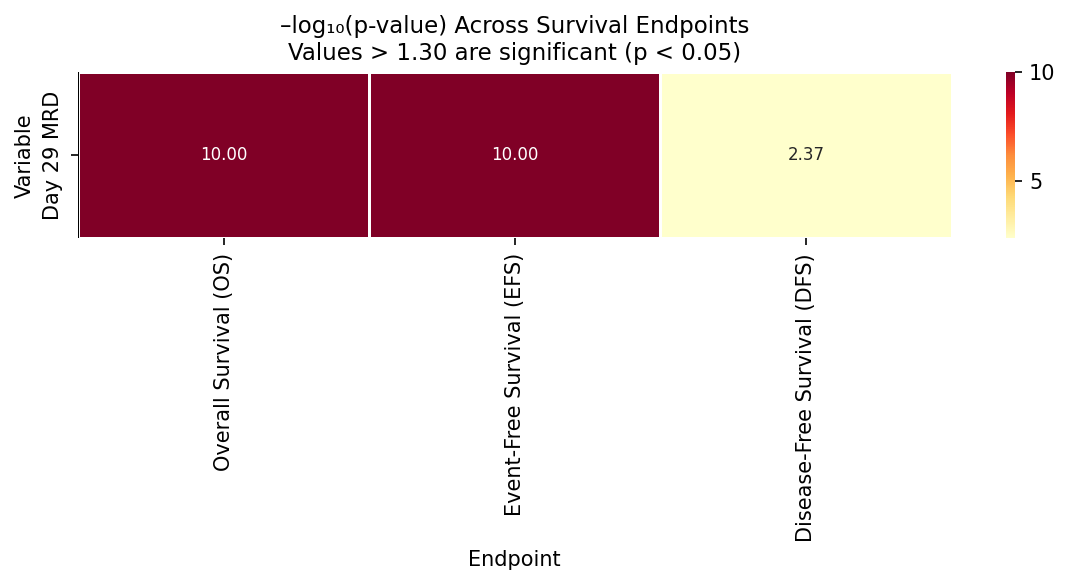


  Significance heatmap → TARGET_univariate_cox_outputs/05_significance_heatmap.png


In [17]:
combined_rows = []
for ep_label, results_df in all_results.items():
    combined_rows.append(results_df)
 
if combined_rows:
    combined_df = pd.concat(combined_rows, ignore_index=True)
    combined_df.to_csv(f"{output_dir}/05_all_univariate_results.csv", index=False)
    print(f"  Combined results → {output_dir}/05_all_univariate_results.csv")

sig_vars_per_endpoint = {}
for ep_label, results_df in all_results.items():
    sig = results_df[results_df['significant']]['variable'].tolist()
    sig_vars_per_endpoint[ep_label] = sig
    safe = ep_label.replace(" ", "_").replace("(", "").replace(")", "")
    pd.Series(sig, name="variable").to_csv(
        f"{output_dir}/05_significant_vars_{safe}.csv", index=False)
    print(f"  {ep_label}: {len(sig)} significant variables → "
          f"{output_dir}/05_significant_vars_{safe}.csv")
    if sig:
        for v in sig:
            row = results_df[results_df['variable'] == v].iloc[0]
            print(f"    {v:<45} HR={row['HR']:.3f}  p={row['p_value']:.4f}")
            
print("\n  Variables significant in ≥2 endpoints (most robust):")
from collections import Counter
all_sig_flat = [v for vlist in sig_vars_per_endpoint.values() for v in vlist]
sig_counts   = Counter(all_sig_flat)
robust_vars  = [v for v, cnt in sig_counts.items() if cnt >= 2]
 
if robust_vars:
    for v in robust_vars:
        eps = [ep for ep, vlist in sig_vars_per_endpoint.items() if v in vlist]
        print(f"    {v:<45} significant in: {eps}")
    pd.DataFrame({"variable": robust_vars}).to_csv(
        f"{output_dir}/05_robust_vars_multi_endpoint.csv", index=False)
else:
    print("    None (no variables significant in ≥2 endpoints)")

if len(all_results) >= 2:
    pivot_data = {}
    all_vars_union = list({v for vlist in sig_vars_per_endpoint.values()
                           for v in vlist})
    for ep_label, results_df in all_results.items():
        pivot_data[ep_label] = {}
        for var in all_vars_union:
            row = results_df[results_df['variable'] == var]
            p   = float(row['p_value'].values[0]) if not row.empty else 1.0
            pivot_data[ep_label][var] = -np.log10(max(p, 1e-10))
 
    heatmap_df = pd.DataFrame(pivot_data).fillna(0)
    # Sort by mean –log10(p) descending
    heatmap_df = heatmap_df.loc[heatmap_df.mean(axis=1).sort_values(
        ascending=False).index]
    
    if not heatmap_df.empty:
        fig, ax = plt.subplots(figsize=(8, max(4, len(heatmap_df) * 0.45 + 1.5)))
        sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd',
                    ax=ax, linewidths=0.5, annot_kws={"size": 8})
        ax.axvline(x=0, color='black', lw=0.5)
        # Significance line: –log10(0.05) = 1.30
        ax.set_title(f"–log₁₀(p-value) Across Survival Endpoints\n"
                     f"Values > 1.30 are significant (p < 0.05)",
                     fontsize=11)
        ax.set_xlabel("Endpoint", fontsize=10)
        ax.set_ylabel("Variable", fontsize=10)
        plt.tight_layout()
        plt.show()
        plt.savefig(f"{output_dir}/05_significance_heatmap.png",
                    bbox_inches='tight')
        plt.close()
        print(f"\n  Significance heatmap → {output_dir}/05_significance_heatmap.png")

In [18]:
print("\n" + "=" * 70)
print("UNIVARIATE COX REGRESSION COMPLETE — SUMMARY")
print("=" * 70)
print(f"  Variables tested    : {len(all_candidate_vars)}")
print(f"  Significance cutoff : p < {p_threshold}")
print()


UNIVARIATE COX REGRESSION COMPLETE — SUMMARY
  Variables tested    : 7
  Significance cutoff : p < 0.1



In [19]:
for ep_label, results_df in all_results.items():
    n_sig = results_df['significant'].sum()
    n_tot = len(results_df)
    sig_names = results_df[results_df['significant']]['variable'].tolist()
    print(f"  {ep_label}:")
    print(f"    Significant: {n_sig} / {n_tot}")
    if sig_names:
        print(f"    Variables  : {sig_names}")
    print()

  Overall Survival (OS):
    Significant: 1 / 5
    Variables  : ['Day 29 MRD']

  Event-Free Survival (EFS):
    Significant: 1 / 5
    Variables  : ['Day 29 MRD']

  Disease-Free Survival (DFS):
    Significant: 1 / 5
    Variables  : ['Day 29 MRD']



In [20]:
print(f"  Robust (≥2 endpoints): {robust_vars}")
print()
print("  Files written to:", output_dir)
outputs = [
    "01_univariate_cox_Overall_Survival_OS.csv",
    "01_univariate_cox_Event-Free_Survival_EFS.csv",
    "01_univariate_cox_Disease-Free_Survival_DFS.csv",
    "02_forest_plot_Overall_Survival_OS.png",
    "02_forest_plot_Event-Free_Survival_EFS.png",
    "02_forest_plot_Disease-Free_Survival_DFS.png",
    "03_ph_assumption_check.csv",
    "04_KM_significant_OS.png",
    "04_KM_MRD_OS_highlight.png",
    "05_all_univariate_results.csv",
    "05_significant_vars_Overall_Survival_OS.csv",
    "05_robust_vars_multi_endpoint.csv",
    "05_significance_heatmap.png",
]
for f in outputs:
    print(f"  ├── {f}")
 
print()
print("  NEXT STEPS:")
print("  1. Review 03_ph_assumption_check.csv")
print("     → Stratify or use time-split for any PH-violated variables")
print("  2. Use 05_significant_vars_Overall_Survival_OS.csv")
print("     → Input for Multivariate Cox Regression (Python)")
print("  3. Use 05_all_univariate_results.csv")
print("     → Input for LASSO Cox Regression (R)")
print("=" * 70)

  Robust (≥2 endpoints): ['Day 29 MRD']

  Files written to: TARGET_univariate_cox_outputs
  ├── 01_univariate_cox_Overall_Survival_OS.csv
  ├── 01_univariate_cox_Event-Free_Survival_EFS.csv
  ├── 01_univariate_cox_Disease-Free_Survival_DFS.csv
  ├── 02_forest_plot_Overall_Survival_OS.png
  ├── 02_forest_plot_Event-Free_Survival_EFS.png
  ├── 02_forest_plot_Disease-Free_Survival_DFS.png
  ├── 03_ph_assumption_check.csv
  ├── 04_KM_significant_OS.png
  ├── 04_KM_MRD_OS_highlight.png
  ├── 05_all_univariate_results.csv
  ├── 05_significant_vars_Overall_Survival_OS.csv
  ├── 05_robust_vars_multi_endpoint.csv
  ├── 05_significance_heatmap.png

  NEXT STEPS:
  1. Review 03_ph_assumption_check.csv
     → Stratify or use time-split for any PH-violated variables
  2. Use 05_significant_vars_Overall_Survival_OS.csv
     → Input for Multivariate Cox Regression (Python)
  3. Use 05_all_univariate_results.csv
     → Input for LASSO Cox Regression (R)
